---
title: MLP from Scratch on MNIST
category: Deep Learning
tags:
  - deep learning
  - mlp
  - backpropagation
  - mnist
  - numpy
date: 2026-07-31
description: Implement a small multilayer perceptron with NumPy and train it on real handwritten digit data.
notebook_page: false
aliases:
  - /deep-learning/mlp-from-scratch-on-mnist
sources:
  - https://huggingface.co/datasets/ylecun/mnist
  - https://numpy.org/numpy-tutorials/tutorial-deep-learning-on-mnist/
---

## Goal

Build a small multilayer perceptron from scratch with NumPy, train it on the real [MNIST dataset](https://huggingface.co/datasets/ylecun/mnist), and inspect where the implementation earns its accuracy. The main point is not raw leaderboard performance. The point is to expose each tensor in the forward and backward pass.

## Why This Dataset

MNIST is small enough to train on a laptop and still rich enough to show the shape of supervised learning. The input is a \(28 \times 28\) image flattened into \(784\) features. The target is one of \(10\) classes.

We will fit

$$
x \\in \\mathbb{R}^{784} \\rightarrow h = \\text{ReLU}(x W_1 + b_1) \\rightarrow \\hat{y} = \\text{softmax}(h W_2 + b_2).
$$

The loss for a minibatch of size \(B\) is

$$
\\mathcal{L} = -\\frac{1}{B} \\sum_{i=1}^{B} \\log p_{i, y_i}.
$$


In [1]:
## Uncomment this if you are running in a fresh environment.
## %pip install -q datasets numpy matplotlib

import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from datasets import load_dataset

np.random.seed(7)
random.seed(7)


/Users/elimelt/Documents/Codex/2026-07-30/github-plugin-github-openai-curated-remote-2/work/notes/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ds = load_dataset("ylecun/mnist")

x_train = np.stack([np.array(example["image"], dtype=np.float32).reshape(-1) for example in ds["train"]]) / 255.0
y_train = np.array(ds["train"]["label"], dtype=np.int64)
x_test = np.stack([np.array(example["image"], dtype=np.float32).reshape(-1) for example in ds["test"]]) / 255.0
y_test = np.array(ds["test"]["label"], dtype=np.int64)

x_train = x_train[:20000]
y_train = y_train[:20000]

print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)


(20000, 784) (20000,) (10000, 784) (10000,)


## NumPy Model

The hidden layer is

$$
H = \\max(0, XW_1 + b_1)
$$

and the logits are

$$
Z = HW_2 + b_2.
$$

After the softmax, the derivative of cross-entropy with respect to the logits is

$$
\\frac{\\partial \\mathcal{L}}{\\partial Z} = \\frac{P - Y}{B},
$$

where \(P\) is the predicted probability matrix and \(Y\) is the one-hot target matrix.


In [3]:
def one_hot(y: np.ndarray, num_classes: int) -> np.ndarray:
    out = np.zeros((len(y), num_classes), dtype=np.float32)
    out[np.arange(len(y)), y] = 1.0
    return out


def relu(x: np.ndarray) -> np.ndarray:
    return np.maximum(x, 0.0)


def relu_grad(x: np.ndarray) -> np.ndarray:
    return (x > 0).astype(np.float32)


def softmax(logits: np.ndarray) -> np.ndarray:
    shifted = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def cross_entropy(probs: np.ndarray, y: np.ndarray) -> float:
    eps = 1e-9
    return float(-np.log(probs[np.arange(len(y)), y] + eps).mean())


@dataclass
class MLP:
    hidden_dim: int = 256
    input_dim: int = 784
    output_dim: int = 10

    def __post_init__(self) -> None:
        scale1 = math.sqrt(2.0 / self.input_dim)
        scale2 = math.sqrt(2.0 / self.hidden_dim)
        self.W1 = np.random.randn(self.input_dim, self.hidden_dim).astype(np.float32) * scale1
        self.b1 = np.zeros((1, self.hidden_dim), dtype=np.float32)
        self.W2 = np.random.randn(self.hidden_dim, self.output_dim).astype(np.float32) * scale2
        self.b2 = np.zeros((1, self.output_dim), dtype=np.float32)

    def forward(self, x: np.ndarray) -> tuple[np.ndarray, dict[str, np.ndarray]]:
        z1 = x @ self.W1 + self.b1
        h1 = relu(z1)
        z2 = h1 @ self.W2 + self.b2
        probs = softmax(z2)
        cache = {"x": x, "z1": z1, "h1": h1, "z2": z2, "probs": probs}
        return probs, cache

    def backward(self, cache: dict[str, np.ndarray], y: np.ndarray) -> dict[str, np.ndarray]:
        x = cache["x"]
        z1 = cache["z1"]
        h1 = cache["h1"]
        probs = cache["probs"].copy()
        batch_size = len(y)

        probs[np.arange(batch_size), y] -= 1.0
        probs /= batch_size

        dW2 = h1.T @ probs
        db2 = probs.sum(axis=0, keepdims=True)
        dh1 = probs @ self.W2.T
        dz1 = dh1 * relu_grad(z1)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0, keepdims=True)
        return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2}

    def step(self, grads: dict[str, np.ndarray], lr: float) -> None:
        self.W1 -= lr * grads["W1"]
        self.b1 -= lr * grads["b1"]
        self.W2 -= lr * grads["W2"]
        self.b2 -= lr * grads["b2"]


In [4]:
def accuracy(model: MLP, x: np.ndarray, y: np.ndarray, batch_size: int = 512) -> float:
    preds = []
    for start in range(0, len(x), batch_size):
        xb = x[start : start + batch_size]
        probs, _ = model.forward(xb)
        preds.append(probs.argmax(axis=1))
    pred = np.concatenate(preds)
    return float((pred == y).mean())


def iterate_minibatches(x: np.ndarray, y: np.ndarray, batch_size: int):
    idx = np.random.permutation(len(x))
    for start in range(0, len(x), batch_size):
        batch_idx = idx[start : start + batch_size]
        yield x[batch_idx], y[batch_idx]


model = MLP(hidden_dim=256)
history = {"train_loss": [], "train_acc": [], "test_acc": []}

epochs = 12
lr = 0.08
batch_size = 256

for epoch in range(epochs):
    losses = []
    for xb, yb in iterate_minibatches(x_train, y_train, batch_size):
        probs, cache = model.forward(xb)
        loss = cross_entropy(probs, yb)
        grads = model.backward(cache, yb)
        model.step(grads, lr=lr)
        losses.append(loss)

    train_acc = accuracy(model, x_train[:4000], y_train[:4000])
    test_acc = accuracy(model, x_test, y_test)
    history["train_loss"].append(float(np.mean(losses)))
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)
    print(f"epoch={epoch:02d} loss={history['train_loss'][-1]:.4f} train_acc={train_acc:.4f} test_acc={test_acc:.4f}")


epoch=00 loss=1.0016 train_acc=0.8632 test_acc=0.8637
epoch=01 loss=0.4673 train_acc=0.8858 test_acc=0.8780
epoch=02 loss=0.3784 train_acc=0.9095 test_acc=0.9027
epoch=03 loss=0.3385 train_acc=0.9193 test_acc=0.9061


epoch=04 loss=0.3081 train_acc=0.9283 test_acc=0.9155


epoch=05 loss=0.2881 train_acc=0.9300 test_acc=0.9202
epoch=06 loss=0.2729 train_acc=0.9353 test_acc=0.9221
epoch=07 loss=0.2587 train_acc=0.9355 test_acc=0.9218
epoch=08 loss=0.2465 train_acc=0.9420 test_acc=0.9274


epoch=09 loss=0.2387 train_acc=0.9435 test_acc=0.9268


epoch=10 loss=0.2259 train_acc=0.9435 test_acc=0.9330
epoch=11 loss=0.2192 train_acc=0.9477 test_acc=0.9306


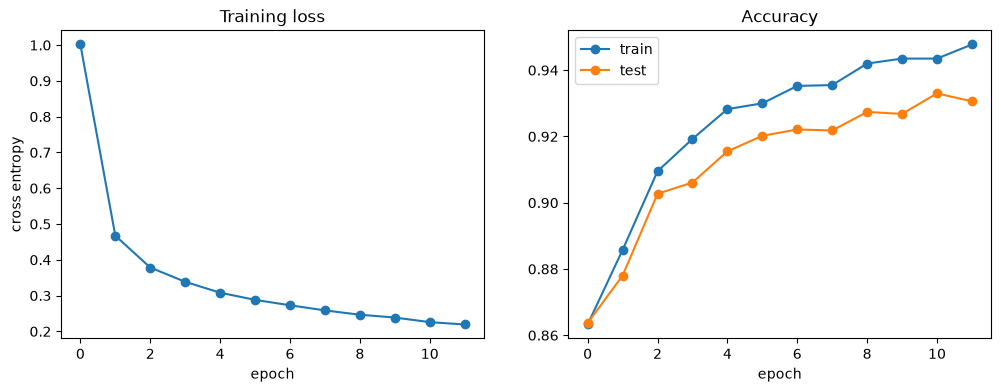

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], marker="o")
axes[0].set_title("Training loss")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("cross entropy")

axes[1].plot(history["train_acc"], marker="o", label="train")
axes[1].plot(history["test_acc"], marker="o", label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.show()


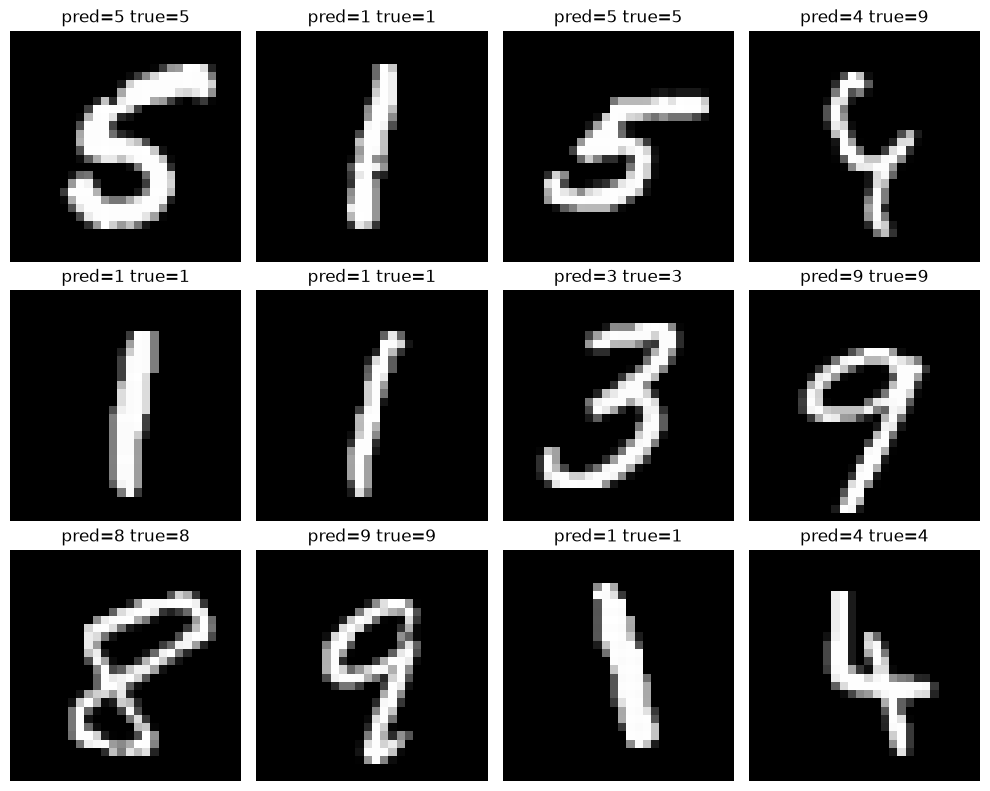

In [6]:
sample_idx = np.random.choice(len(x_test), size=12, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
probs, _ = model.forward(x_test[sample_idx])
preds = probs.argmax(axis=1)

for ax, idx, pred in zip(axes.flat, sample_idx, preds):
    ax.imshow(x_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"pred={pred} true={y_test[idx]}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## What To Extend

A few natural next steps:

1. Replace plain SGD with momentum or Adam and compare convergence.
2. Add another hidden layer and watch how the gradient norms change.
3. Swap the full-batch NumPy implementation for a Torch version and compare ergonomics.
